In [10]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [9]:
import pandas as pd

df = pd.read_csv("../data/dummy_radar_dataset.csv")

print(df.head())

  object_id            timestamp  speed_kmh  altitude_m  direction_deg  \
0    OBJ001  2026-07-03 06:00:07     8004.0    116401.6           36.9   
1    OBJ002  2026-07-03 06:00:14      826.1       450.8          181.9   
2    OBJ003  2026-07-03 06:00:21      750.6     10909.3          100.1   
3    OBJ004  2026-07-03 06:00:28    14902.8     47925.6          344.6   
4    OBJ005  2026-07-03 06:00:35      826.0     10256.4           15.6   

   rcs_sqm  acceleration_g          trajectory_type  distance_from_border_km  \
0    0.111            6.40            Ballistic-Arc                    449.6   
1    0.112            0.44          Terrain-Hugging                     35.4   
2   11.293            0.45                   Linear                    524.2   
3    0.081            4.40  Boost-Glide-Maneuvering                    215.2   
4   67.516            0.13                   Linear                    286.5   

  iff_response            true_class  threat_level  
0           No     Ba

In [11]:
drop_cols = [
    "object_id",
    "timestamp",
    "trajectory_type",
    "iff_response",
    "threat_level"
]

df = df.drop(columns=drop_cols)

In [12]:
df = df.drop(columns=["distance_from_border_km"])

In [13]:
le = LabelEncoder()
df["true_class"] = le.fit_transform(df["true_class"])

In [14]:
X = df.drop("true_class", axis=1)
y = df["true_class"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

Train shape: (160, 5)
Test shape: (40, 5)

Training class distribution:
true_class
0    30
4    26
6    24
2    22
1    21
3    19
5    18
Name: count, dtype: int64


In [16]:
print("\nMissing values:")
print(df.isnull().sum())

print("\nFeature columns:")
print(X.columns)


Missing values:
speed_kmh         0
altitude_m        0
direction_deg     0
rcs_sqm           0
acceleration_g    0
true_class        0
dtype: int64

Feature columns:
Index(['speed_kmh', 'altitude_m', 'direction_deg', 'rcs_sqm',
       'acceleration_g'],
      dtype='str')


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [19]:
y_pred = rf.predict(X_test)

In [20]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9750


In [21]:
# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))


Classification Report:
                      precision    recall  f1-score   support

   Ballistic Missile       1.00      0.86      0.92         7
 Commercial Aircraft       1.00      1.00      1.00         5
      Cruise Missile       1.00      1.00      1.00         6
         Fighter Jet       1.00      1.00      1.00         5
  Hypersonic Missile       0.86      1.00      0.92         6
Private/Civilian Jet       1.00      1.00      1.00         5
           UAV/Drone       1.00      1.00      1.00         6

            accuracy                           0.97        40
           macro avg       0.98      0.98      0.98        40
        weighted avg       0.98      0.97      0.97        40



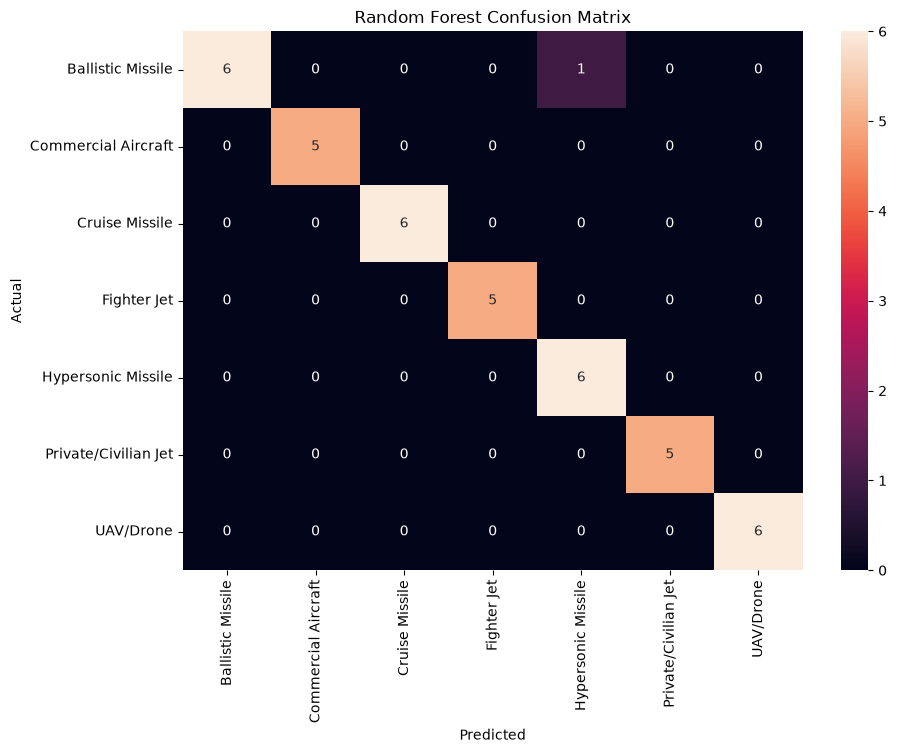

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [24]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    random_state=42
)

param_grid = {
    'max_depth':[3,4,5,6],
    'n_estimators':[100,150,200,300],
    'learning_rate':[0.01,0.05,0.1,0.2],
    'subsample':[0.8,1.0],
    'colsample_bytree':[0.8,1.0]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=15,
    cv=cv,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best Parameters:")
print(search.best_params_)

print("\nBest CV Score:")
print(search.best_score_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

Best CV Score:
0.95


XGBoost Test Accuracy: 0.9500

Classification Report:
                      precision    recall  f1-score   support

   Ballistic Missile       0.86      0.86      0.86         7
 Commercial Aircraft       1.00      1.00      1.00         5
      Cruise Missile       1.00      1.00      1.00         6
         Fighter Jet       1.00      1.00      1.00         5
  Hypersonic Missile       0.86      1.00      0.92         6
Private/Civilian Jet       1.00      0.80      0.89         5
           UAV/Drone       1.00      1.00      1.00         6

            accuracy                           0.95        40
           macro avg       0.96      0.95      0.95        40
        weighted avg       0.95      0.95      0.95        40



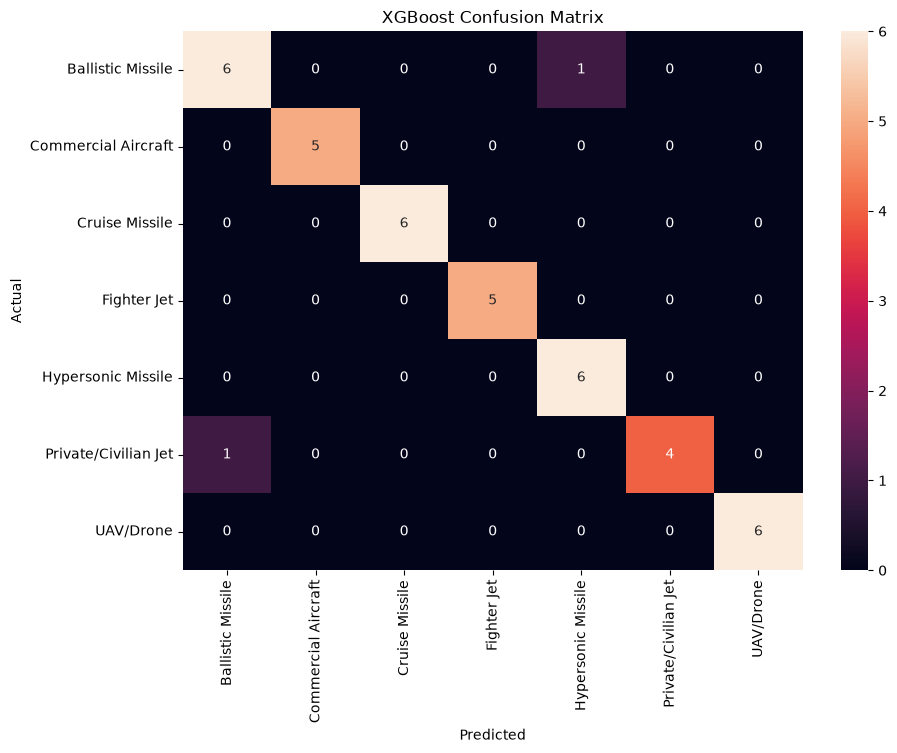

In [25]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Use best model from RandomizedSearchCV
best_xgb = search.best_estimator_

# Predict on test set
y_pred_xgb = best_xgb.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Test Accuracy: {acc:.4f}")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=le.classes_
    )
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.savefig("../results/confusion_matrix.png")
plt.show()

<Figure size 1000x600 with 0 Axes>

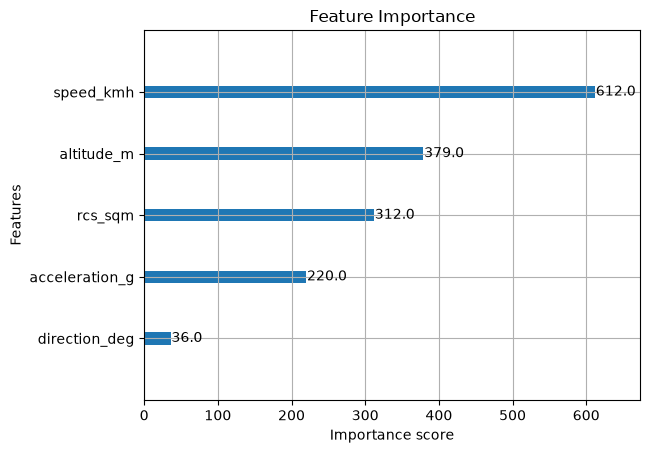

In [26]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plot_importance(
    best_xgb,
    max_num_features=10
)

plt.title("Feature Importance")

plt.savefig("../results/feature_importance.png")
plt.show()

In [27]:
import pickle

with open("../models/xgb_model.pkl", "wb") as f:
    pickle.dump(best_xgb, f)

print("Model saved successfully")

Model saved successfully


In [28]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred_xgb,
    target_names=le.classes_
)

with open("../results/classification_report.txt", "w") as f:
    f.write(report)

print("Classification report saved")

Classification report saved
